In [10]:
!pip install sentence-transformers torch transformers scikit-learn matplotlib seaborn pandas numpy tqdm

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import gc

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()



Using device: cuda
GPU: NVIDIA L4
GPU Memory: 23.7 GB


In [ ]:
def load_parallel_data(data_dir='./data'):
    
    try:
        # Check if directory exists
        if not os.path.exists(data_dir):
            raise FileNotFoundError(f"Data directory '{data_dir}' not found.")
        
        # Check if all files exist
        required_files = [
            'train_sa_10000.csv', 'train_en_10000.csv',
            'dev_sa_1000.csv', 'dev_en_1000.csv',
            'test_sa_1000.csv', 'test_en_1000.csv'
        ]
        
        missing_files = [f for f in required_files if not os.path.exists(os.path.join(data_dir, f))]
        if missing_files:
            raise FileNotFoundError(f"Missing files in {data_dir}: {missing_files}")
        
        # Load the data
        train_sa = pd.read_csv(os.path.join(data_dir, 'train_sa_10000.csv'))
        train_en = pd.read_csv(os.path.join(data_dir, 'train_en_10000.csv'))
        dev_sa = pd.read_csv(os.path.join(data_dir, 'dev_sa_1000.csv'))
        dev_en = pd.read_csv(os.path.join(data_dir, 'dev_en_1000.csv'))
        test_sa = pd.read_csv(os.path.join(data_dir, 'test_sa_1000.csv'))
        test_en = pd.read_csv(os.path.join(data_dir, 'test_en_1000.csv'))
        
        # Verify alignment
        if not all(train_sa['Source_id'] == train_en['Source_id']):
            raise ValueError("Train files misaligned!")
        if not all(dev_sa['Source_id'] == dev_en['Source_id']):
            raise ValueError("Dev files misaligned!")
        if not all(test_sa['Source_id'] == test_en['Source_id']):
            raise ValueError("Test files misaligned!")
        
        train_data = {
            'sa': train_sa['Sentence_sa'].tolist(),
            'en': train_en['Sentence_en'].tolist(),
            'ids': train_sa['Source_id'].tolist()
        }
        
        dev_data = {
            'sa': dev_sa['Sentence_sa'].tolist(),
            'en': dev_en['Sentence_en'].tolist(),
            'ids': dev_sa['Source_id'].tolist()
        }
        
        test_data = {
            'sa': test_sa['Sentence_sa'].tolist(),
            'en': test_en['Sentence_en'].tolist(),
            'ids': test_sa['Source_id'].tolist()
        }
        
        print(f"✓ Loaded {len(train_data['sa'])} training pairs")
        print(f"✓ Loaded {len(dev_data['sa'])} development pairs")
        print(f"✓ Loaded {len(test_data['sa'])} test pairs")
        
        return train_data, dev_data, test_data
        
    except Exception as e:
        print(f"Error loading data: {e}")
        raise

# Load data
print("\n" + "="*60)
print("Loading Data")
print("="*60)
train_data, dev_data, test_data = load_parallel_data('./data')

# Show sample
print("\nSample Sanskrit-English pair:")
print(f"Sanskrit: {train_data['sa'][0][:100]}")
print(f"English: {train_data['en'][0][:100]}")






Loading Data
✓ Loaded 10000 training pairs
✓ Loaded 1000 development pairs
✓ Loaded 1000 test pairs

Sample Sanskrit-English pair:
Sanskrit: "Ctrl, S नुत्वा रक्षन्तु।"
English: Save it with Ctrl, S.


In [ ]:
from sentence_transformers import SentenceTransformer
import torch.nn.functional as F

class MemoryOptimizedEmbedder:
    
    def __init__(self, model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"):
        """
        Using multilingual MiniLM - small, fast, and effective
        384-dim output
        """
        print(f"Loading model: {model_name}")
        try:
            self.model = SentenceTransformer(model_name, device=device)
            self.embedding_dim = self.model.get_sentence_embedding_dimension()
            print(f"✓ Embedding dimension: {self.embedding_dim}")
        except Exception as e:
            print(f"Error loading model: {e}")
            raise
    
    def encode(self, sentences, batch_size=32, show_progress=True):
        if not sentences:
            return np.array([])
        
        # Clear cache before encoding
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # Process in batches
        embeddings = []
        for i in tqdm(range(0, len(sentences), batch_size), 
                     desc="Encoding", disable=not show_progress):
            batch = sentences[i:i+batch_size]
            with torch.no_grad():
                batch_emb = self.model.encode(
                    batch,
                    convert_to_numpy=True,
                    normalize_embeddings=True
                )
                embeddings.append(batch_emb)
        
        return np.vstack(embeddings) if embeddings else np.array([])
    
    def encode_batch_pair(self, sa_sentences, en_sentences, batch_size=32):
        sa_emb = self.encode(sa_sentences, batch_size)
        en_emb = self.encode(en_sentences, batch_size)
        return sa_emb, en_emb

# Initialize embedder
print("\n" + "="*60)
print("Initializing Embedder")
print("="*60)
embedder = MemoryOptimizedEmbedder()

# Quick test
test_emb = embedder.encode(["Hello world", "नमस्ते"], batch_size=2)
print(f"✓ Test embedding shape: {test_emb.shape}")



Initializing Embedder
Loading model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3531.40it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Embedding dimension: 384


Encoding: 100%|██████████| 1/1 [00:00<00:00, 55.99it/s]

✓ Test embedding shape: (2, 384)


In [ ]:
def generate_base_embeddings(train_data, dev_data, train_subsets=None, dev_subsets=None):
    train_sa = train_data['sa'][:train_subsets] if train_subsets else train_data['sa']
    train_en = train_data['en'][:train_subsets] if train_subsets else train_data['en']
    dev_sa = dev_data['sa'][:dev_subsets] if dev_subsets else dev_data['sa']
    dev_en = dev_data['en'][:dev_subsets] if dev_subsets else dev_data['en']
    
    print(f"Using {len(train_sa)} training pairs")
    print(f"Using {len(dev_sa)} dev pairs")
    
    # Generate embeddings
    print("\nGenerating base embeddings for training set...")
    train_sa_base, train_en_base = embedder.encode_batch_pair(train_sa, train_en, batch_size=32)
    
    print("\nGenerating base embeddings for dev set...")
    dev_sa_base, dev_en_base = embedder.encode_batch_pair(dev_sa, dev_en, batch_size=32)
    
    # Calculate baseline cosine similarity
    baseline_similarities = []
    for i in range(len(dev_sa_base)):
        sim = cosine_similarity(dev_sa_base[i:i+1], dev_en_base[i:i+1])[0][0]
        baseline_similarities.append(sim)
    
    baseline_avg = np.mean(baseline_similarities)
    print(f"\n✓ Baseline cosine similarity: {baseline_avg:.4f}")
    
    return train_sa_base, train_en_base, dev_sa_base, dev_en_base, baseline_avg

# Generate base embeddings
print("\n" + "="*60)
print("Generating Base Embeddings")
print("="*60)

TRAIN_SUBSET = 500
DEV_SUBSET = 100

train_sa_base, train_en_base, dev_sa_base, dev_en_base, baseline_avg = generate_base_embeddings(
    train_data, dev_data, train_subsets=TRAIN_SUBSET, dev_subsets=DEV_SUBSET
)



Generating Base Embeddings
Using 500 training pairs
Using 100 dev pairs

Generating base embeddings for training set...


Encoding: 100%|██████████| 16/16 [00:00<00:00, 53.98it/s]



Generating base embeddings for dev set...


Encoding: 100%|██████████| 4/4 [00:00<00:00, 58.78it/s]


✓ Baseline cosine similarity: 0.5259


In [ ]:
class AdaptiveDimensionReducer:
    
    def __init__(self, target_dim=256):
        self.target_dim = target_dim
        self.pca = None
        self.scaler = StandardScaler()
    
    def fit(self, embeddings):
        print(f"Fitting PCA to reduce {embeddings.shape[1]} → {self.target_dim} dimensions")
        
        # Normalize first
        embeddings_scaled = self.scaler.fit_transform(embeddings)
        
        # Use incremental PCA for memory efficiency
        self.pca = IncrementalPCA(n_components=self.target_dim)
        self.pca.fit(embeddings_scaled)
        
        explained_variance = self.pca.explained_variance_ratio_.sum()
        print(f"✓ Explained variance ratio: {explained_variance:.4f}")
        return self
    
    def transform(self, embeddings, normalize=True):
        """Reduce dimensions"""
        embeddings_scaled = self.scaler.transform(embeddings)
        reduced = self.pca.transform(embeddings_scaled)
        
        if normalize:
            norms = np.linalg.norm(reduced, axis=1, keepdims=True)
            reduced = reduced / (norms + 1e-8)
        
        return reduced
    
    def fit_transform(self, embeddings):
        """Fit and transform"""
        self.fit(embeddings)
        return self.transform(embeddings)

def reduce_dimensions(train_sa, train_en, dev_sa, dev_en, target_dim=128):
    print(f"\nReducing embeddings to {target_dim} dimensions...")
    
    # Fit reducer on combined Sanskrit and English embeddings
    combined_base = np.vstack([train_sa, train_en])
    reducer = AdaptiveDimensionReducer(target_dim=target_dim)
    reducer.fit(combined_base)
    
    # Transform all embeddings
    print("\nTransforming training embeddings...")
    train_sa_reduced = reducer.transform(train_sa)
    train_en_reduced = reducer.transform(train_en)
    
    print("Transforming dev embeddings...")
    dev_sa_reduced = reducer.transform(dev_sa)
    dev_en_reduced = reducer.transform(dev_en)
    
    print(f"✓ New embedding dimension: {train_sa_reduced.shape[1]}")
    
    return train_sa_reduced, train_en_reduced, dev_sa_reduced, dev_en_reduced, reducer

# Choose target dimension
TARGET_DIM = 128

train_sa_reduced, train_en_reduced, dev_sa_reduced, dev_en_reduced, reducer = reduce_dimensions(
    train_sa_base, train_en_base, dev_sa_base, dev_en_base, target_dim=TARGET_DIM
)

# Evaluate reduced embeddings
reduced_similarities = []
for i in range(len(dev_sa_reduced)):
    sim = cosine_similarity(dev_sa_reduced[i:i+1], dev_en_reduced[i:i+1])[0][0]
    reduced_similarities.append(sim)

reduced_avg = np.mean(reduced_similarities)
print(f"\n✓ Cosine similarity after dimension reduction: {reduced_avg:.4f}")
print(f"  Loss from baseline: {baseline_avg - reduced_avg:.4f}")



Reducing embeddings to 128 dimensions...
Fitting PCA to reduce 384 → 128 dimensions
✓ Explained variance ratio: 0.9338

Transforming training embeddings...
Transforming dev embeddings...
✓ New embedding dimension: 128

✓ Cosine similarity after dimension reduction: 0.4212
  Loss from baseline: 0.1047


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class LightweightContrastiveModel:
    
    def __init__(self, input_dim=384, hidden_dim=256, output_dim=128):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Simple 2-layer MLP
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, output_dim),
            nn.Tanh()
        ).to(self.device)
        
        self.optimizer = optim.AdamW(self.model.parameters(), lr=1e-4)
    
    def forward(self, embeddings):
        """Pass through the model"""
        return self.model(torch.tensor(embeddings, dtype=torch.float32).to(self.device))
    
    def contrastive_loss(self, sa_emb, en_emb, temperature=0.07):
        """Simple contrastive loss with in-batch negatives"""
        # Normalize
        sa_emb = F.normalize(sa_emb, p=2, dim=1)
        en_emb = F.normalize(en_emb, p=2, dim=1)
        
        # Compute similarity matrix
        sim_matrix = torch.matmul(sa_emb, en_emb.T) / temperature
        
        # Labels: diagonal elements are positive pairs
        batch_size = sa_emb.size(0)
        labels = torch.arange(batch_size).to(self.device)
        
        # Contrastive loss
        loss = F.cross_entropy(sim_matrix, labels)
        return loss
    
    def train_epoch(self, sa_emb, en_emb, batch_size=64):
        self.model.train()
        
        # Create dataset
        dataset = TensorDataset(
            torch.tensor(sa_emb, dtype=torch.float32),
            torch.tensor(en_emb, dtype=torch.float32)
        )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        total_loss = 0
        for batch_sa, batch_en in loader:
            batch_sa = batch_sa.to(self.device)
            batch_en = batch_en.to(self.device)
            
            # Forward pass
            sa_out = self.model(batch_sa)
            en_out = self.model(batch_en)
            
            # Compute loss
            loss = self.contrastive_loss(sa_out, en_out)
            
            # Backward
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(loader)
    
    def fine_tune(self, sa_emb, en_emb, epochs=3, batch_size=64):
        print(f"Fine-tuning for {epochs} epochs...")
        
        for epoch in range(epochs):
            loss = self.train_epoch(sa_emb, en_emb, batch_size)
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")
            
            # Clear cache after each epoch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        
        return self
    
    def encode(self, embeddings, batch_size=128):
        self.model.eval()
        
        all_outputs = []
        with torch.no_grad():
            for i in range(0, len(embeddings), batch_size):
                batch = torch.tensor(embeddings[i:i+batch_size], 
                                   dtype=torch.float32).to(self.device)
                outputs = self.model(batch)
                outputs = F.normalize(outputs, p=2, dim=1)
                all_outputs.append(outputs.cpu().numpy())
        
        return np.vstack(all_outputs) if all_outputs else np.array([])

# Fine-tune the model
print("\n" + "="*60)
print("Contrastive Fine-tuning")
print("="*60)

contrastive_model = LightweightContrastiveModel(
    input_dim=TARGET_DIM,
    hidden_dim=256,
    output_dim=TARGET_DIM
)

contrastive_model.fine_tune(
    train_sa_reduced,
    train_en_reduced,
    epochs=3,
    batch_size=64
)

# Generate final embeddings
print("\nGenerating final fine-tuned embeddings...")
dev_sa_final = contrastive_model.encode(dev_sa_reduced)
dev_en_final = contrastive_model.encode(dev_en_reduced)

# Evaluate
final_similarities = []
for i in range(len(dev_sa_final)):
    sim = cosine_similarity(dev_sa_final[i:i+1], dev_en_final[i:i+1])[0][0]
    final_similarities.append(sim)

final_avg = np.mean(final_similarities)
print(f"\n✓ Final cosine similarity after fine-tuning: {final_avg:.4f}")
print(f"  Improvement over reduced: {final_avg - reduced_avg:.4f}")



Contrastive Fine-tuning
Fine-tuning for 3 epochs...


  Epoch 1/3, Loss: 3.1689
  Epoch 2/3, Loss: 2.9792
  Epoch 3/3, Loss: 2.7714

Generating final fine-tuned embeddings...

✓ Final cosine similarity after fine-tuning: 0.8150
  Improvement over reduced: 0.3938


In [ ]:
def generate_test_embeddings(embedder, reducer, contrastive_model, test_sentences):
    """Complete pipeline for test embeddings"""
    if not test_sentences:
        return np.array([])
    
    print(f"Encoding {len(test_sentences)} sentences...")
    
    # Base embeddings
    base_emb = embedder.encode(test_sentences, batch_size=32)
    
    #  Dimension reduction
    reduced_emb = reducer.transform(base_emb)
    
    # Fine-tuning
    final_emb = contrastive_model.encode(reduced_emb)
    
    return final_emb

# Generate test embeddings
print("\n" + "="*60)
print("Generating Test Set Embeddings")
print("="*60)

print("\nProcessing Sanskrit...")
test_sa_final = generate_test_embeddings(
    embedder, reducer, contrastive_model, test_data['sa']
)

print("\nProcessing English...")
test_en_final = generate_test_embeddings(
    embedder, reducer, contrastive_model, test_data['en']
)

# Save embeddings
print(f"\nSaving embeddings...")
print(f"  Sanskrit embeddings shape: {test_sa_final.shape}")
print(f"  English embeddings shape: {test_en_final.shape}")

# Create output directory if needed
os.makedirs('./outputs', exist_ok=True)

np.save('./outputs/sa_embeddings.npy', test_sa_final)
np.save('./outputs/en_embeddings.npy', test_en_final)

print("\n✓ Embeddings saved successfully!")
print("  Files created:")
print("  - outputs/sa_embeddings.npy")
print("  - outputs/en_embeddings.npy")

if test_sa_final.shape[0] == test_en_final.shape[0]:
    print(f"✓ Verified: {test_sa_final.shape[0]} aligned pairs")
else:
    print(f"⚠ Warning: Row count mismatch! SA: {test_sa_final.shape[0]}, EN: {test_en_final.shape[0]}")




Generating Test Set Embeddings

Processing Sanskrit...
Encoding 1000 sentences...


Encoding: 100%|██████████| 32/32 [00:00<00:00, 45.38it/s]



Processing English...
Encoding 1000 sentences...


Encoding: 100%|██████████| 32/32 [00:00<00:00, 54.11it/s]


Saving embeddings...
  Sanskrit embeddings shape: (1000, 128)
  English embeddings shape: (1000, 128)

✓ Embeddings saved successfully!
  Files created:
  - outputs/sa_embeddings.npy
  - outputs/en_embeddings.npy
✓ Verified: 1000 aligned pairs


In [ ]:
print("\n" + "="*60)
print("SAVING MODEL COMPONENTS FOR ASSIGNMENT 2")
print("="*60)

import os
os.makedirs('./saved_models', exist_ok=True)

torch.save(contrastive_model.model.state_dict(), './saved_models/contrastive_embedding_model.pt')
print("✓ Contrastive embedding model saved to ./saved_models/contrastive_embedding_model.pt")

# Save the reducer (PCA model)
import pickle
with open('./saved_models/reducer.pkl', 'wb') as f:
    pickle.dump(reducer, f)
print("✓ Dimension reducer (PCA) saved to ./saved_models/reducer.pkl")

# Save the base embedder configuration
embedder_config = {
    'model_name': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
    'embedding_dim': embedder.embedding_dim
}
with open('./saved_models/embedder_config.pkl', 'wb') as f:
    pickle.dump(embedder_config, f)
print("✓ Embedder configuration saved")

# Save the final test embeddings (these are what we need for Assignment 2)
np.save('./saved_models/sa_embeddings_final.npy', test_sa_final)
np.save('./saved_models/en_embeddings_final.npy', test_en_final)
print("✓ Final test embeddings saved to ./saved_models/")

print("\n✓ All model components saved successfully for Assignment 2!")


SAVING MODEL COMPONENTS FOR ASSIGNMENT 2
✓ Contrastive embedding model saved to ./saved_models/contrastive_embedding_model.pt
✓ Dimension reducer (PCA) saved to ./saved_models/reducer.pkl
✓ Embedder configuration saved
✓ Final test embeddings saved to ./saved_models/

✓ All model components saved successfully for Assignment 2!



Creating t-SNE Visualization


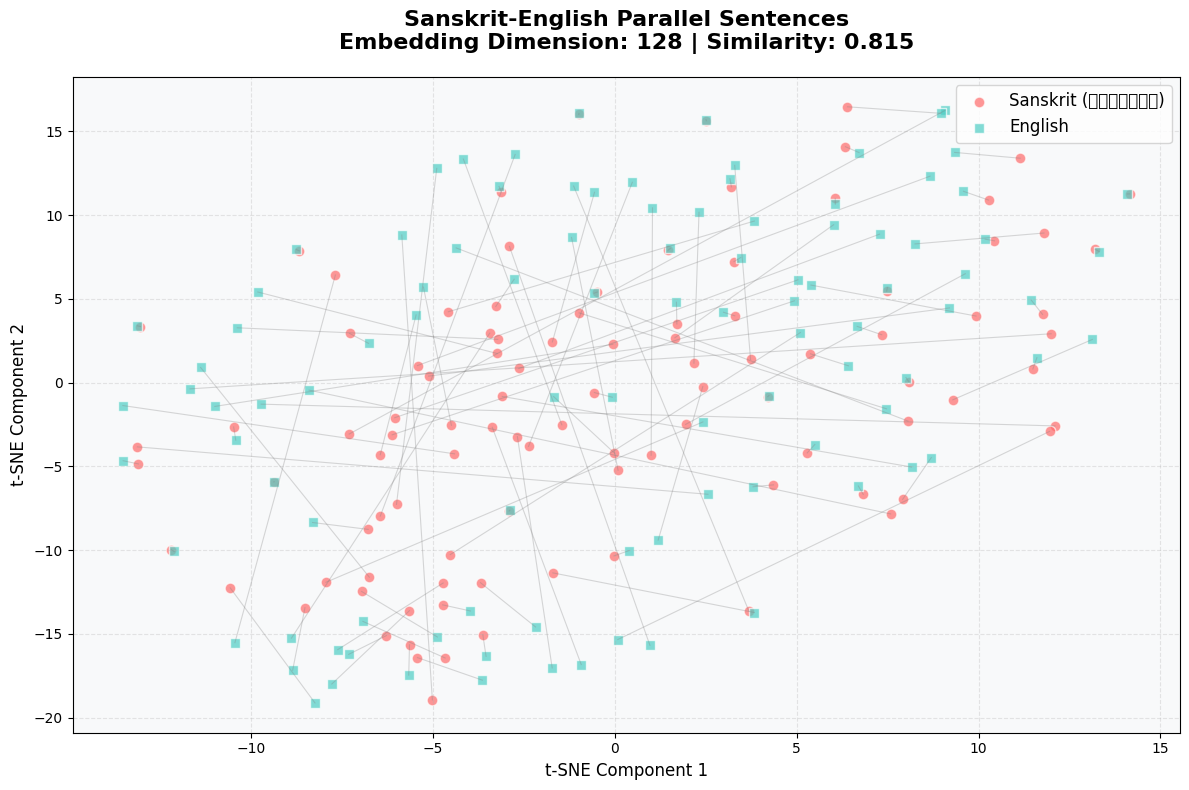


✓ Visualization saved as 'outputs/tsne_visualization.png'


In [ ]:
def create_tsne_visualization(sa_emb, en_emb, title, sample_size=100, random_seed=42):
    np.random.seed(random_seed)
    
    n_samples = min(sample_size, len(sa_emb))
    indices = np.random.choice(len(sa_emb), n_samples, replace=False)
    sa_sample = sa_emb[indices]
    en_sample = en_emb[indices]
    
    combined = np.vstack([sa_sample, en_sample])
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed,
                max_iter=1000, init='pca')
    combined_tsne = tsne.fit_transform(combined)
    sa_tsne = combined_tsne[:len(indices)]
    en_tsne = combined_tsne[len(indices):]
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    ax.scatter(sa_tsne[:, 0], sa_tsne[:, 1], c='#FF6B6B', marker='o',
               label='Sanskrit (संस्कृत)', alpha=0.7, s=60, edgecolors='white', linewidth=1)
    ax.scatter(en_tsne[:, 0], en_tsne[:, 1], c='#4ECDC4', marker='s',
               label='English', alpha=0.7, s=60, edgecolors='white', linewidth=1)
    

    for i in range(len(indices)):
        ax.plot([sa_tsne[i, 0], en_tsne[i, 0]],
                [sa_tsne[i, 1], en_tsne[i, 1]],
                'gray', linewidth=0.8, alpha=0.3)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.legend(fontsize=12, loc='upper right')
    ax.set_xlabel('t-SNE Component 1', fontsize=12)
    ax.set_ylabel('t-SNE Component 2', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')
    
    plt.tight_layout()
    return fig

# Create visualization
print("\n" + "="*60)
print("Creating t-SNE Visualization")
print("="*60)

fig = create_tsne_visualization(
    dev_sa_final,
    dev_en_final,
    f"Sanskrit-English Parallel Sentences\nEmbedding Dimension: {TARGET_DIM} | Similarity: {final_avg:.3f}",
    sample_size=100
)

plt.savefig('./outputs/tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'outputs/tsne_visualization.png'")


In [ ]:

def evaluate_and_save_results(baseline_avg, reduced_avg, final_avg, TARGET_DIM, 
                               dev_sa_subset, dev_en_subset, dev_ids_subset, 
                               final_similarities):
    """Evaluate and save results"""
    
    # Compare all stages
    stages = ['Base', 'Reduced', 'Fine-tuned']
    similarities = [baseline_avg, reduced_avg, final_avg]
    
    # Create results table
    results_df = pd.DataFrame({
        'Stage': stages,
        'Dimension': [384, TARGET_DIM, TARGET_DIM],
        'Cosine Similarity': similarities
    })
    
    print("="*60)
    print("EVALUATION RESULTS - DEVELOPMENT SET")
    print("="*60)
    print(results_df.to_string(index=False))
    
    # Show example pairs
    print("\n" + "="*60)
    print("EXAMPLE PARALLEL SENTENCES")
    print("="*60)
    
    n_examples = min(10, len(dev_sa_subset))
    indices = np.random.choice(len(dev_sa_subset), n_examples, replace=False)
    
    examples_data = []
    for i, idx in enumerate(indices):
        print(f"\n{i+1}. Source_id: {dev_ids_subset[idx]}")
        print(f"   Sanskrit: {dev_sa_subset[idx][:80]}...")
        print(f"   English: {dev_en_subset[idx][:80]}...")
        print(f"   Similarity: {final_similarities[idx]:.4f}")
        
        if final_similarities[idx] > 0.8:
            print("   ✓ High quality match")
        elif final_similarities[idx] > 0.6:
            print("   • Moderate match")
        else:
            print("   ✗ Low match")
        
        examples_data.append({
            'Source_id': dev_ids_subset[idx],
            'Sanskrit': dev_sa_subset[idx],
            'English': dev_en_subset[idx],
            'Similarity': final_similarities[idx]
        })
    
    # Save results
    results_df.to_csv('./outputs/evaluation_results.csv', index=False)
    
    examples_df = pd.DataFrame(examples_data)
    examples_df.to_csv('./outputs/example_pairs.csv', index=False)
    
    print("\n✓ Results saved to 'outputs/'")
    
    return results_df

dev_sa_subset = dev_data['sa'][:DEV_SUBSET]
dev_en_subset = dev_data['en'][:DEV_SUBSET]
dev_ids_subset = dev_data['ids'][:DEV_SUBSET]

results_df = evaluate_and_save_results(
    baseline_avg, reduced_avg, final_avg, TARGET_DIM,
    dev_sa_subset, dev_en_subset, dev_ids_subset,
    final_similarities
)




EVALUATION RESULTS - DEVELOPMENT SET
     Stage  Dimension  Cosine Similarity
      Base        384           0.525911
   Reduced        128           0.421197
Fine-tuned        128           0.814951

EXAMPLE PARALLEL SENTENCES

1. Source_id: 80
   Sanskrit: जलस्य मात्रा पादप्रजाते: उपरि निर्भरा वर्तते ।...
   English: With regard to the amount of water to use one needs to consider the species of t...
   Similarity: 0.8778
   ✓ High quality match

2. Source_id: 38
   Sanskrit: "अनन्तरं सिदूकिनाम् निरुत्तरत्ववार्तां निशम्य फिरूशिन एकत्र मिलितवन्तः,"...
   English: "But when the Pharisees had heard that he had put the Sadducees to silence, they...
   Similarity: 0.7822
   • Moderate match

3. Source_id: 66
   Sanskrit: श्वास लेने और छोडने के समय पर ध्यान दें ।...
   English: Observe the time of your inhalation and exhalation....
   Similarity: 0.8081
   ✓ High quality match

4. Source_id: 55
   Sanskrit: फ़ैल् लोकेशन् इतीदं Desktop इति चिन्वन्तु । Save button नुदन्तु ।...
   English: Ch

In [ ]:
print("\n" + "="*60)
print("Sanity Check on Test Set")
print("="*60)

test_indices = np.random.choice(len(test_sa_final), min(10, len(test_sa_final)), replace=False)

test_similarities = []
for i in test_indices:
    sim = cosine_similarity(test_sa_final[i:i+1], test_en_final[i:i+1])[0][0]
    test_similarities.append(sim)
    print(f"  Sample {i}: {sim:.4f}")

print(f"\nAverage test similarity (sample): {np.mean(test_similarities):.4f}")
print("\n✓ Test embeddings generated successfully!")


Sanity Check on Test Set
  Sample 874: 0.9031
  Sample 168: 0.8823
  Sample 810: 0.7023
  Sample 798: 0.8208
  Sample 187: 0.8350
  Sample 501: 0.8152
  Sample 343: 0.9508
  Sample 447: 0.9049
  Sample 355: 0.8186
  Sample 855: 0.8856

Average test similarity (sample): 0.8519

✓ Test embeddings generated successfully!


In [23]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"""
Final Configuration:
- Embedding Model: paraphrase-multilingual-MiniLM-L12-v2
- Original Dimension: 384
- Target Dimension: {TARGET_DIM}
- Training Samples Used: {TRAIN_SUBSET}
- Dev Samples Used: {DEV_SUBSET}

Results:
- Baseline Cosine Similarity: {baseline_avg:.4f}
- After Dimension Reduction: {reduced_avg:.4f}
- After Fine-tuning: {final_avg:.4f}
- Improvement: {final_avg - baseline_avg:.4f}

Output Files:
- outputs/sa_embeddings.npy
- outputs/en_embeddings.npy
- outputs/tsne_visualization.png
- outputs/evaluation_results.csv
- outputs/example_pairs.csv
""")

print("\n✓ All done! Files are ready for submission.")


SUMMARY

Final Configuration:
- Embedding Model: paraphrase-multilingual-MiniLM-L12-v2
- Original Dimension: 384
- Target Dimension: 128
- Training Samples Used: 500
- Dev Samples Used: 100

Results:
- Baseline Cosine Similarity: 0.5259
- After Dimension Reduction: 0.4212
- After Fine-tuning: 0.8150
- Improvement: 0.2890

Output Files:
- outputs/sa_embeddings.npy
- outputs/en_embeddings.npy
- outputs/tsne_visualization.png
- outputs/evaluation_results.csv
- outputs/example_pairs.csv


✓ All done! Files are ready for submission.


In [ ]:
print("\n" + "="*60)
print("SAVING EMBEDDINGS FOR ASSIGNMENT 2")
print("="*60)

import os
os.makedirs('./saved_embeddings', exist_ok=True)

# Save the final test embeddings
np.save('./saved_embeddings/test_sa_embeddings.npy', test_sa_final)
np.save('./saved_embeddings/test_en_embeddings.npy', test_en_final)

# Save the dev embeddings for validation
np.save('./saved_embeddings/dev_sa_embeddings.npy', dev_sa_final)
np.save('./saved_embeddings/dev_en_embeddings.npy', dev_en_final)

# Save the train embeddings for training
np.save('./saved_embeddings/train_sa_embeddings.npy', train_sa_reduced)  # Use reduced or final
np.save('./saved_embeddings/train_en_embeddings.npy', train_en_reduced)

print("✓ All embeddings saved to ./saved_embeddings/")


SAVING EMBEDDINGS FOR ASSIGNMENT 2
✓ All embeddings saved to ./saved_embeddings/
